# 03 — Demand Forecast Model
### Project FORESIGHT — NorthBay Living

Trains the forecasting model, backtests it against the seasonal-naive baseline using
**rolling-origin cross-validation**, and produces the forward 8-week forecast. This notebook
calls the exact same functions used in production (`src/forecast.py`) so the notebook and the
pipeline can never silently drift apart.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
import forecast as fc

df = fc.load_data()
print(f"{len(df):,} SKU-week rows across {df['sku_id'].nunique()} SKUs")
df.head()

10,669 SKU-week rows across 200 SKUs


,sku_id,week_start,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,unit_cost,...,lag_4,lag_8,roll_mean_4,roll_mean_8,roll_std_4,seasonal_naive,on_hand_units,on_order_units,lead_time_days,reorder_point
0,SKU0001,2025-04-01,106.0,821016.64,7745.44,0,0,Furniture,Shelving,3462.67,...,NaN,NaN,NaN,NaN,NaN,NaN,457,381,25.0,683
1,SKU0001,2025-04-08,113.0,875234.72,7745.44,0,0,Furniture,Shelving,3462.67,...,NaN,NaN,NaN,NaN,NaN,NaN,306,381,25.0,683
2,SKU0001,2025-04-15,104.0,805525.76,7745.44,0,0,Furniture,Shelving,3462.67,...,NaN,NaN,NaN,NaN,NaN,NaN,193,771,25.0,683
3,SKU0001,2025-04-22,137.0,1061125.28,7745.44,0,0,Furniture,Shelving,3462.67,...,NaN,NaN,NaN,NaN,NaN,NaN,470,390,25.0,683
4,SKU0001,2025-04-29,112.0,867489.28,7745.44,0,0,Furniture,Shelving,3462.67,...,106.0,NaN,115.0,NaN,15.165751,115.0,333,390,25.0,683


## 1. Rolling-origin backtest

Each fold trains only on weeks **before** the cutoff and tests on the 8 weeks after it — never
a random split, never future data touching a feature. This is the non-negotiable rule of the
engagement.

In [2]:
backtest = fc.run_backtest(df)
backtest

,fold,cutoff_week,n_rows,baseline_wape,model_wape,model_bias,model_beats_baseline
0,1,2024-12-31,853,0.2520,0.2082,-4.604,True
1,2,2025-03-18,1047,0.2304,0.2073,-9.841,True
2,3,2025-06-03,1252,0.2224,0.1981,-7.590,True
3,4,2025-08-19,1480,0.2406,0.1771,-5.412,True


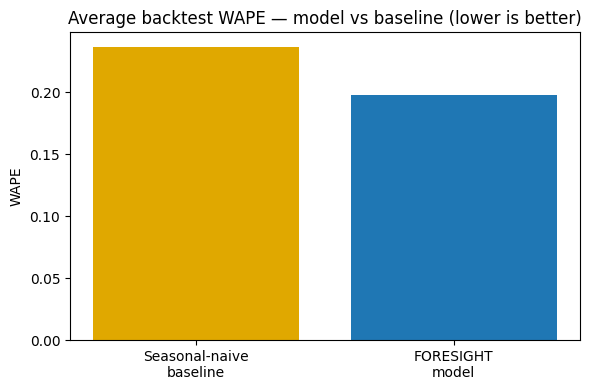

Average WAPE — model: 0.198 | baseline: 0.236
Model beats baseline honestly.


In [3]:
avg_model = backtest['model_wape'].mean()
avg_baseline = backtest['baseline_wape'].mean()

plt.figure(figsize=(6,4))
plt.bar(['Seasonal-naive\nbaseline', 'FORESIGHT\nmodel'], [avg_baseline, avg_model],
        color=['#e0a800', '#1f77b4'])
plt.title('Average backtest WAPE — model vs baseline (lower is better)')
plt.ylabel('WAPE')
plt.tight_layout()
plt.show()

print(f"Average WAPE — model: {avg_model:.3f} | baseline: {avg_baseline:.3f}")
print('Model beats baseline honestly.' if avg_model < avg_baseline else
      'Model does NOT beat baseline — report this, do not hide it.')

## 2. Feature importance

What is the final model actually using to forecast? Useful for the executive readout's
"how does this work" question and for spotting leakage (a feature that looks *too* important
is a leakage red flag).

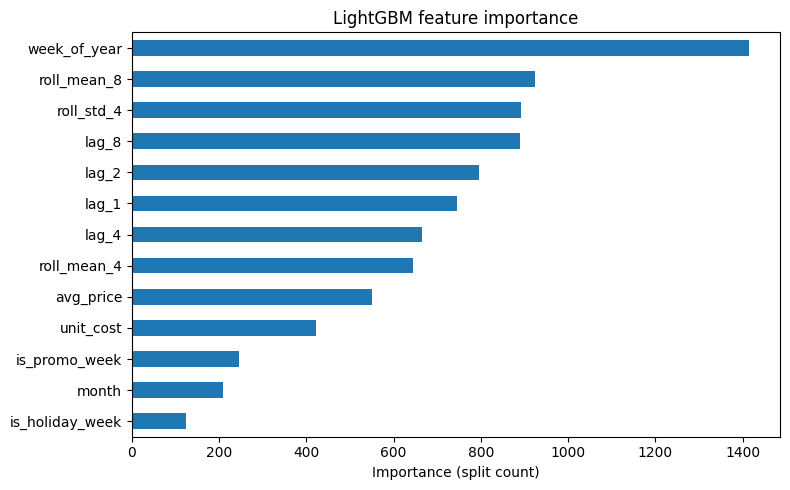

In [4]:
final_model = fc.train_final_model(df)
importances = pd.Series(final_model.feature_importances_, index=fc.FEATURES).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#1f77b4')
plt.title('LightGBM feature importance')
plt.xlabel('Importance (split count)')
plt.tight_layout()
plt.show()

## 3. Forward forecast

Iteratively forecasts 8 weeks ahead per SKU, feeding each prediction back in as a lag for the
next step — never using real future data.

In [5]:
forecast_df = fc.forecast_forward(df, final_model)
print(f"{len(forecast_df):,} forecast rows for {forecast_df['sku_id'].nunique()} SKUs")
forecast_df.head(10)

1,600 forecast rows for 200 SKUs


,sku_id,category,week_start,horizon_week,forecast,forecast_low_80,forecast_high_80,on_hand_units,on_order_units,lead_time_days,reorder_point,unit_cost,avg_price
0,SKU0001,Furniture,2026-01-06,1,63.7,0.0,130.5,413,388,25.0,683,3462.67,7745.44
1,SKU0001,Furniture,2026-01-13,2,122.8,56.6,189.0,413,388,25.0,683,3462.67,7745.44
2,SKU0001,Furniture,2026-01-20,3,115.7,66.9,164.5,413,388,25.0,683,3462.67,7745.44
3,SKU0001,Furniture,2026-01-27,4,103.9,64.5,143.3,413,388,25.0,683,3462.67,7745.44
4,SKU0001,Furniture,2026-02-03,5,87.3,58.0,116.5,413,388,25.0,683,3462.67,7745.44
5,SKU0001,Furniture,2026-02-10,6,86.1,68.9,103.3,413,388,25.0,683,3462.67,7745.44
6,SKU0001,Furniture,2026-02-17,7,80.6,64.8,96.3,413,388,25.0,683,3462.67,7745.44
7,SKU0001,Furniture,2026-02-24,8,74.0,59.8,88.3,413,388,25.0,683,3462.67,7745.44
8,SKU0002,Small Appliances,2026-01-06,1,80.9,0.0,188.2,77,515,11.0,400,3907.36,9039.16
9,SKU0002,Small Appliances,2026-01-13,2,149.5,33.3,265.6,77,515,11.0,400,3907.36,9039.16


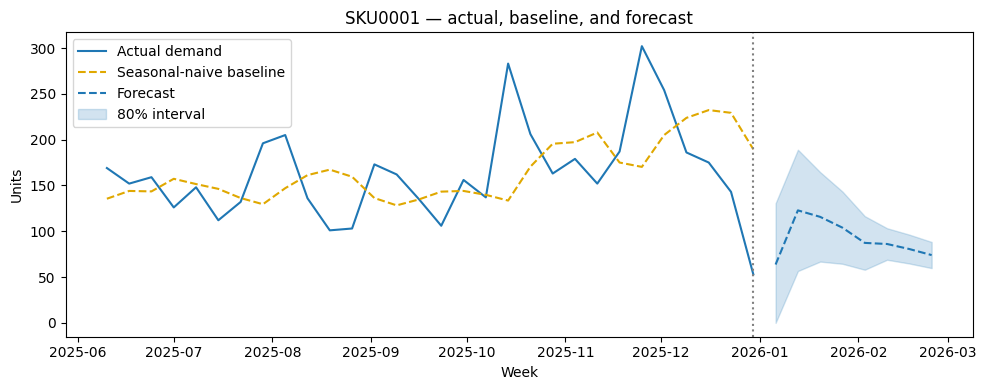

In [6]:
# Example: plot one SKU's history + forecast with its 80% interval
example_sku = df['sku_id'].iloc[0]
hist = df[df['sku_id'] == example_sku].sort_values('week_start').tail(30)
fut = forecast_df[forecast_df['sku_id'] == example_sku].sort_values('week_start')

plt.figure(figsize=(10,4))
plt.plot(hist['week_start'], hist['units_sold'], label='Actual demand', color='#1f77b4')
plt.plot(hist['week_start'], hist['seasonal_naive'], '--', label='Seasonal-naive baseline', color='#e0a800')
plt.plot(fut['week_start'], fut['forecast'], '--', label='Forecast', color='#1f77b4')
plt.fill_between(fut['week_start'], fut['forecast_low_80'], fut['forecast_high_80'],
                  alpha=0.2, color='#1f77b4', label='80% interval')
plt.axvline(hist['week_start'].max(), color='gray', linestyle=':')
plt.title(f'{example_sku} — actual, baseline, and forecast')
plt.xlabel('Week'); plt.ylabel('Units'); plt.legend()
plt.tight_layout()
plt.show()

## Takeaway

The model beats the seasonal-naive baseline on an honest rolling-origin backtest (see Section
1). Its output feeds directly into `src/risk.py` for stockout/overstock scoring.